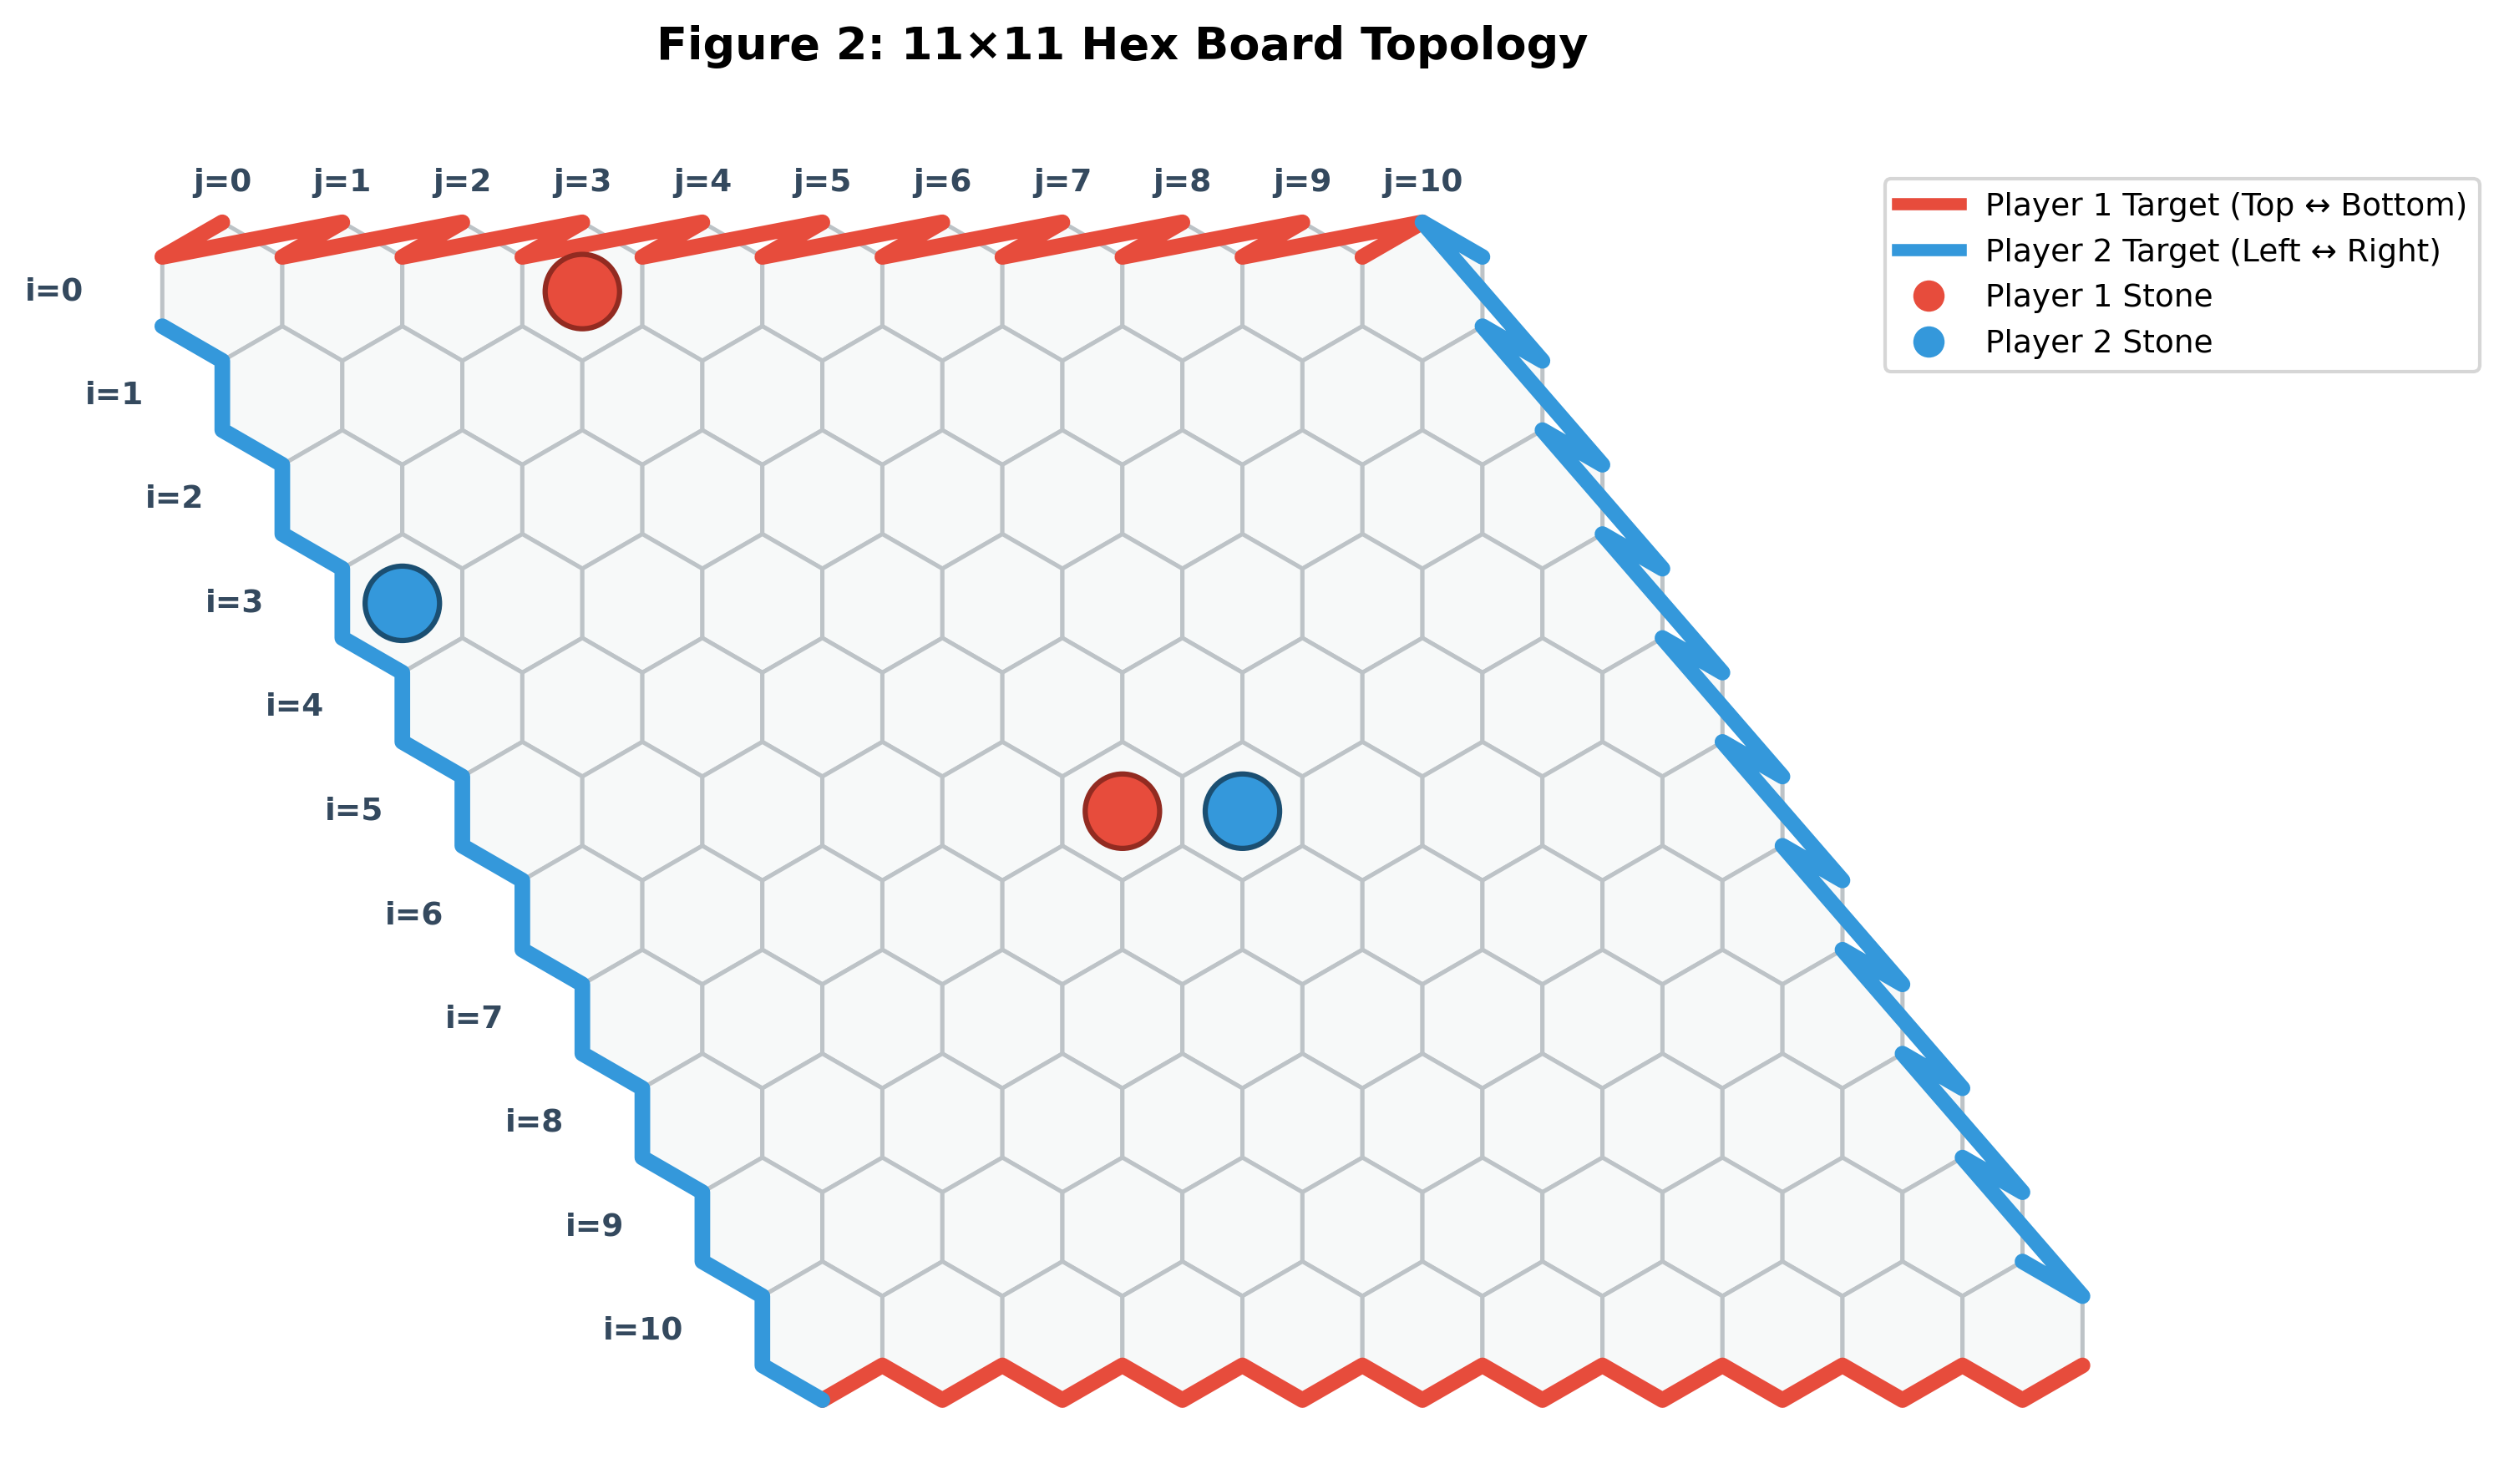

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Polygon, Circle
from matplotlib.lines import Line2D

class HexState:
    def __init__(self, board_size=11, board=None, turn=1):
        self.board_size = board_size
        self.turn = turn
        if board is None:
            self.board = np.zeros((board_size, board_size), dtype=int)
        else:
            self.board = np.copy(board)
        self._cached_winner = None
        self._is_terminal_cached = False

    def get_legal_moves(self):
        if self.is_terminal(): return []
        rows, cols = np.where(self.board == 0)
        return list(zip(rows, cols))

    def make_move(self, move):
        row, col = move
        next_board = np.copy(self.board)
        next_board[row, col] = self.turn
        return HexState(self.board_size, next_board, 3 - self.turn)

    def get_neighbors(self, row, col):
        neighbors = []
        directions = [(row-1, col), (row-1, col+1), (row, col-1), 
                      (row, col+1), (row+1, col-1), (row+1, col)]
        for r, c in directions:
            if 0 <= r < self.board_size and 0 <= c < self.board_size:
                neighbors.append((r, c))
        return neighbors

    def check_winner(self):
        if self._cached_winner is not None: return self._cached_winner
        if self._has_connected_path(player=1): 
            self._cached_winner = 1
            return 1
        if self._has_connected_path(player=2): 
            self._cached_winner = 2
            return 2
        return None

    def _has_connected_path(self, player):
        queue = []
        visited = set()
        if player == 1:
            for c in range(self.board_size):
                if self.board[0, c] == 1:
                    queue.append((0, c))
                    visited.add((0, c))
        else:
            for r in range(self.board_size):
                if self.board[r, 0] == 2:
                    queue.append((r, 0))
                    visited.add((r, 0))
        while queue:
            curr_r, curr_c = queue.pop(0)
            if player == 1 and curr_r == self.board_size - 1: return True
            if player == 2 and curr_c == self.board_size - 1: return True
            for nr, nc in self.get_neighbors(curr_r, curr_c):
                if self.board[nr, nc] == player and (nr, nc) not in visited:
                    visited.add((nr, nc))
                    queue.append((nr, nc))
        return False

    def is_terminal(self):
        if self._is_terminal_cached: return True
        if self.check_winner() is not None:
            self._is_terminal_cached = True
            return True
        if not np.any(self.board == 0):
            self._is_terminal_cached = True
            return True
        return False


def draw_hex_board(state, filename="hex_board_11x11.png"):
    board_size = state.board_size
    fig, ax = plt.subplots(figsize=(10, 8), dpi=300)
    ax.set_aspect("equal")
    ax.axis("off")

    R = 1.0  
    r = R * np.sqrt(3) / 2  

    def hex_center(row, col):
        x = col * np.sqrt(3) * R + row * (np.sqrt(3) / 2 * R)
        y = -row * 1.5 * R
        return x, y

    def get_hex_vertices(cx, cy):
        angles = np.deg2rad(np.arange(30, 390, 60))
        vx = cx + R * np.cos(angles)
        vy = cy + R * np.sin(angles)
        return list(zip(vx, vy))

    # 1. Cells and Stones
    for r_idx in range(board_size):
        for c_idx in range(board_size):
            cx, cy = hex_center(r_idx, c_idx)
            verts = get_hex_vertices(cx, cy)
            
            # Hex tile
            poly = Polygon(verts, facecolor="#F7F9F9", edgecolor="#BDC3C7", linewidth=1.2, zorder=1)
            ax.add_patch(poly)

            # Outer Axis Labels (i, j)
            if r_idx == 0:  # Column labels (j) on top
                ax.text(cx, cy + 1.35, f"j={c_idx}", fontsize=9, ha="center", va="bottom", color="#34495E", fontweight="bold")
            if c_idx == 0:  # Row labels (i) on left - shifted further out with right-alignment
                ax.text(cx - 2.0, cy, f"i={r_idx}", fontsize=9, ha="right", va="center", color="#34495E", fontweight="bold")

            # Stone markers
            val = state.board[r_idx, c_idx]
            if val == 1:
                ax.add_patch(Circle((cx, cy), radius=0.62 * r, facecolor="#E74C3C", edgecolor="#922B21", linewidth=1.5, zorder=4))
            elif val == 2:
                ax.add_patch(Circle((cx, cy), radius=0.62 * r, facecolor="#3498DB", edgecolor="#1B4F72", linewidth=1.5, zorder=4))

    # 2. Goal Boundaries
    top_points, bottom_points, left_points, right_points = [], [], [], []
    for c in range(board_size):
        verts_t = get_hex_vertices(*hex_center(0, c))
        top_points.extend([verts_t[1], verts_t[2]])
        verts_b = get_hex_vertices(*hex_center(board_size - 1, c))
        bottom_points.extend([verts_b[4], verts_b[5]])

    for r_idx in range(board_size):
        verts_l = get_hex_vertices(*hex_center(r_idx, 0))
        left_points.extend([verts_l[3], verts_l[4]])
        verts_r = get_hex_vertices(*hex_center(r_idx, board_size - 1))
        right_points.extend([verts_r[0], verts_r[1]])

    ax.plot(*zip(*top_points), color="#E74C3C", linewidth=4.5, solid_capstyle="round", zorder=3)
    ax.plot(*zip(*bottom_points), color="#E74C3C", linewidth=4.5, solid_capstyle="round", zorder=3)
    ax.plot(*zip(*left_points), color="#3498DB", linewidth=4.5, solid_capstyle="round", zorder=3)
    ax.plot(*zip(*right_points), color="#3498DB", linewidth=4.5, solid_capstyle="round", zorder=3)

    # 3. Legend & Title
    legend_elements = [
        Line2D([0], [0], color="#E74C3C", lw=3.5, label="Player 1 Target (Top ↔ Bottom)"),
        Line2D([0], [0], color="#3498DB", lw=3.5, label="Player 2 Target (Left ↔ Right)"),
        Line2D([0], [0], marker='o', color='w', markerfacecolor='#E74C3C', markersize=10, label="Player 1 Stone"),
        Line2D([0], [0], marker='o', color='w', markerfacecolor='#3498DB', markersize=10, label="Player 2 Stone")
    ]
    ax.legend(handles=legend_elements, loc="upper right", frameon=True, fontsize=9, bbox_to_anchor=(1.15, 1.0))
    ax.set_title("Figure 2: 11×11 Hex Board Topology", fontsize=13, fontweight="bold", pad=30)

    ax.autoscale_view()
    plt.tight_layout()
    plt.savefig(filename, dpi=300, bbox_inches="tight")
    plt.show()

# Execute Sample
hex_game = HexState(board_size=11)
hex_game = hex_game.make_move((5, 5))
hex_game = hex_game.make_move((5, 6))
hex_game = hex_game.make_move((0, 3))
hex_game = hex_game.make_move((3, 0))
draw_hex_board(hex_game, filename="hex_board_11x11.png")

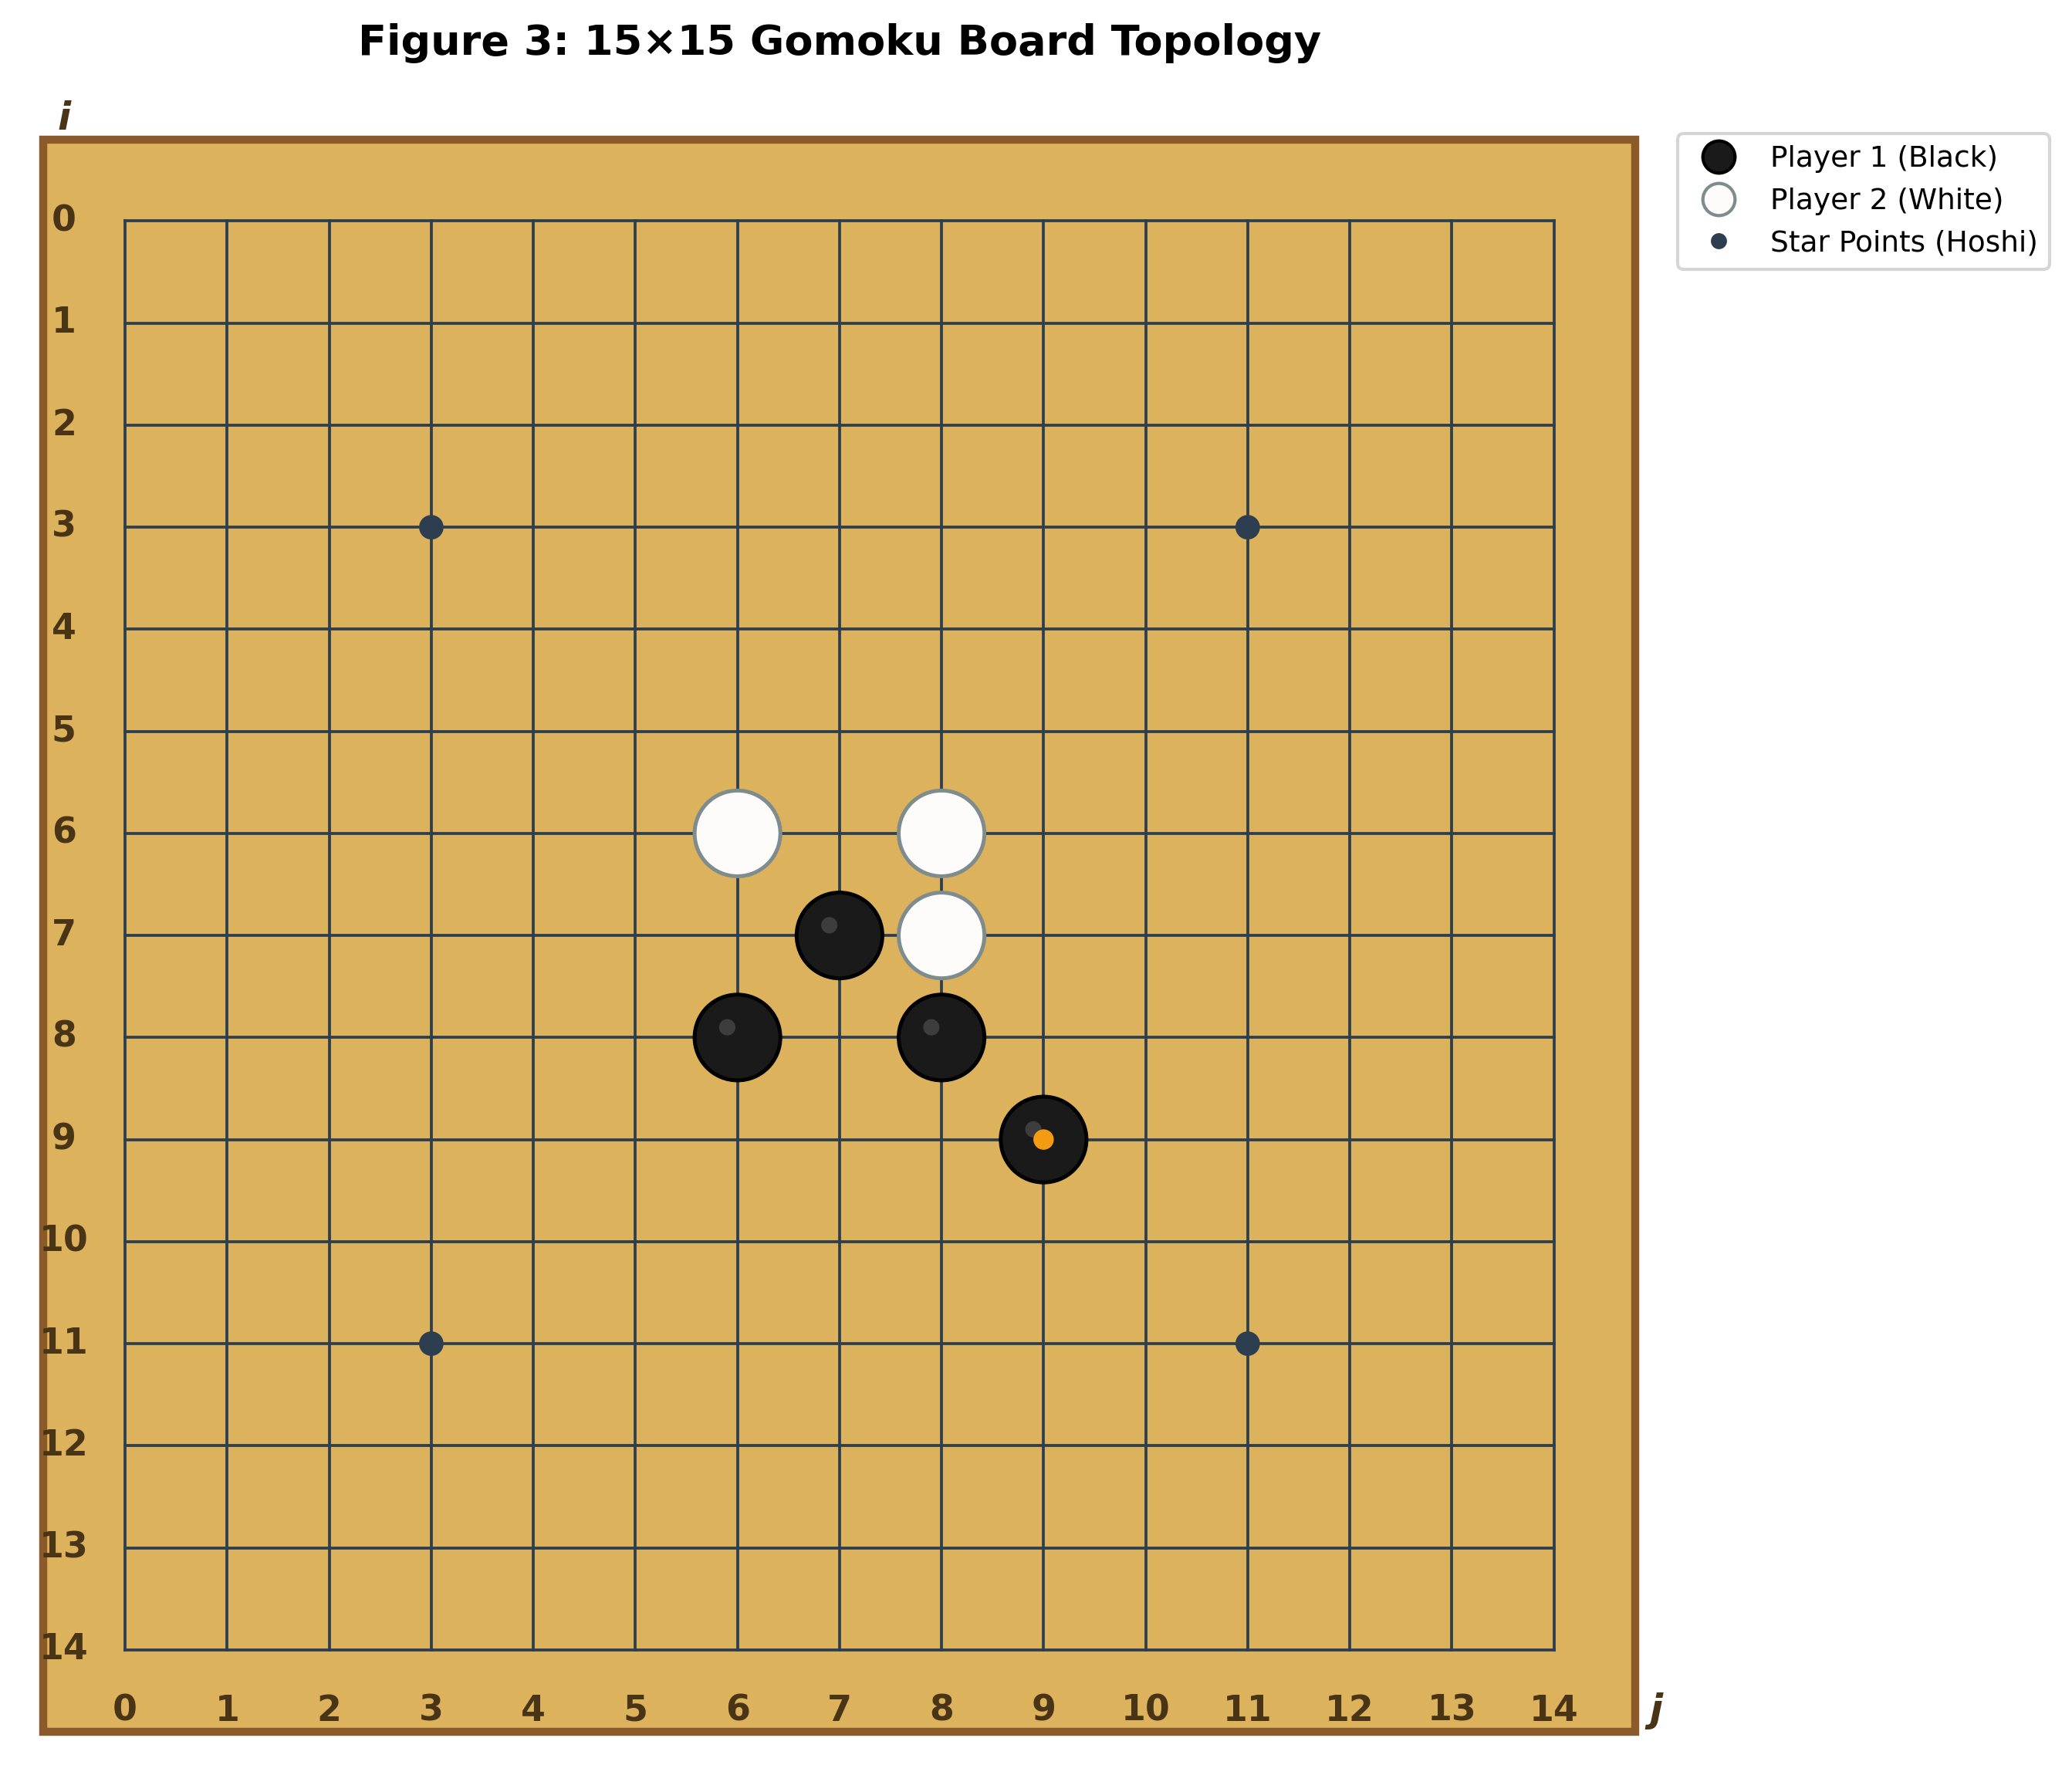

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Circle
from matplotlib.lines import Line2D

class GomokuState:
    def __init__(self, board_size=15, board=None, turn=1, last_move=None):
        self.board_size = board_size
        self.turn = turn
        self.last_move = last_move
        if board is None:
            self.board = np.zeros((board_size, board_size), dtype=int)
        else:
            self.board = np.copy(board)
        self._cached_winner = None
        self._is_terminal_cached = False

    def get_legal_moves(self):
        if self.is_terminal(): return []
        rows, cols = np.where(self.board == 0)
        return list(zip(rows, cols))

    def make_move(self, move):
        row, col = move
        next_board = np.copy(self.board)
        next_board[row, col] = self.turn
        return GomokuState(self.board_size, next_board, 3 - self.turn, last_move=move)

    def check_winner(self):
        if self._cached_winner is not None: return self._cached_winner
        if self.last_move is None: return None
        r, c = self.last_move
        player = self.board[r, c]
        directions = [(0, 1), (1, 0), (1, 1), (1, -1)]
        for dr, dc in directions:
            count = 1
            for step_dir in [1, -1]:
                step = 1
                while True:
                    nr, nc = r + (dr * step * step_dir), c + (dc * step * step_dir)
                    if 0 <= nr < self.board_size and 0 <= nc < self.board_size and self.board[nr, nc] == player:
                        count += 1
                        step += 1
                    else:
                        break
            if count >= 5:
                self._cached_winner = player
                return player
        return None

    def is_terminal(self):
        if self._is_terminal_cached: return True
        if self.check_winner() is not None:
            self._is_terminal_cached = True
            return True
        if not np.any(self.board == 0):
            self._is_terminal_cached = True
            return True
        return False

def draw_gomoku_board(state, filename="gomoku_board_15x15.png"):
    board_size = state.board_size
    fig, ax = plt.subplots(figsize=(9, 9), dpi=300)
    ax.set_aspect("equal")

    # Board background
    board_bg = plt.Rectangle((-0.8, -0.8), board_size + 0.6, board_size + 0.6, 
                             facecolor="#DCB35C", edgecolor="#8B5A2B", linewidth=2.5, zorder=0)
    ax.add_patch(board_bg)

    # 1. Draw 15x15 Grid Lines
    for i in range(board_size):
        ax.plot([0, board_size - 1], [i, i], color="#2C3E50", linewidth=0.9, zorder=1)
        ax.plot([i, i], [0, board_size - 1], color="#2C3E50", linewidth=0.9, zorder=1)
        
        # Add outer (i, j) axis labels instead of inner coordinates
        ax.text(-0.6, board_size - 1 - i, f"{i}", fontsize=11, ha="center", va="center", color="#4A3416", fontweight="bold") # Rows (i)
        ax.text(i, -0.6, f"{i}", fontsize=11, ha="center", va="center", color="#4A3416", fontweight="bold") # Cols (j)

    ax.text(-0.6, board_size, "i", fontsize=12, ha="center", va="center", color="#4A3416", fontweight="bold", fontstyle="italic")
    ax.text(board_size, -0.6, "j", fontsize=12, ha="center", va="center", color="#4A3416", fontweight="bold", fontstyle="italic")

    # 2. Draw Star Points (Hoshi)
    star_points = [(3, 3), (3, 11), (7, 7), (11, 3), (11, 11)]
    for r, c in star_points:
        star = Circle((c, board_size - 1 - r), radius=0.12, facecolor="#2C3E50", zorder=2)
        ax.add_patch(star)

    # 3. Draw Stones
    for r in range(board_size):
        for c in range(board_size):
            x, y = c, board_size - 1 - r
            val = state.board[r, c]

            if val == 1:
                ax.add_patch(Circle((x, y), radius=0.42, facecolor="#1A1A1A", edgecolor="#000000", linewidth=1.2, zorder=4))
                ax.add_patch(Circle((x - 0.1, y + 0.1), radius=0.08, facecolor="#555555", alpha=0.6, zorder=5))
            elif val == 2:
                ax.add_patch(Circle((x, y), radius=0.42, facecolor="#FDFCFA", edgecolor="#7F8C8D", linewidth=1.2, zorder=4))

    # Highlight Last Move
    if state.last_move is not None:
        lr, lc = state.last_move
        marker_color = "#E74C3C" if state.board[lr, lc] == 2 else "#F39C12"
        ax.add_patch(Circle((lc, board_size - 1 - lr), radius=0.1, facecolor=marker_color, zorder=6))

    # 4. Axes, Legend & Title
    ax.set_xlim(-1, board_size)
    ax.set_ylim(-1, board_size)
    ax.axis("off")

    legend_elements = [
        Line2D([0], [0], marker='o', color='w', markerfacecolor='#1A1A1A', markeredgecolor='#000000', markersize=10, label="Player 1 (Black)"),
        Line2D([0], [0], marker='o', color='w', markerfacecolor='#FDFCFA', markeredgecolor='#7F8C8D', markersize=10, label="Player 2 (White)"),
        Line2D([0], [0], marker='o', color='w', markerfacecolor='#2C3E50', markersize=6, label="Star Points (Hoshi)")
    ]
    ax.legend(handles=legend_elements, loc="upper right", frameon=True, fontsize=9, bbox_to_anchor=(1.25, 1.0))
    ax.set_title("Figure 3: 15×15 Gomoku Board Topology", fontsize=13, fontweight="bold", pad=20)

    plt.tight_layout()
    plt.savefig(filename, dpi=300, bbox_inches="tight")
    plt.show()

# Execute Sample
gomoku_game = GomokuState(board_size=15)
moves = [(7, 7), (7, 8), (8, 6), (6, 8), (8, 8), (6, 6), (9, 9)]
for m in moves:
    gomoku_game = gomoku_game.make_move(m)
draw_gomoku_board(gomoku_game, filename="gomoku_board_15x15.png")

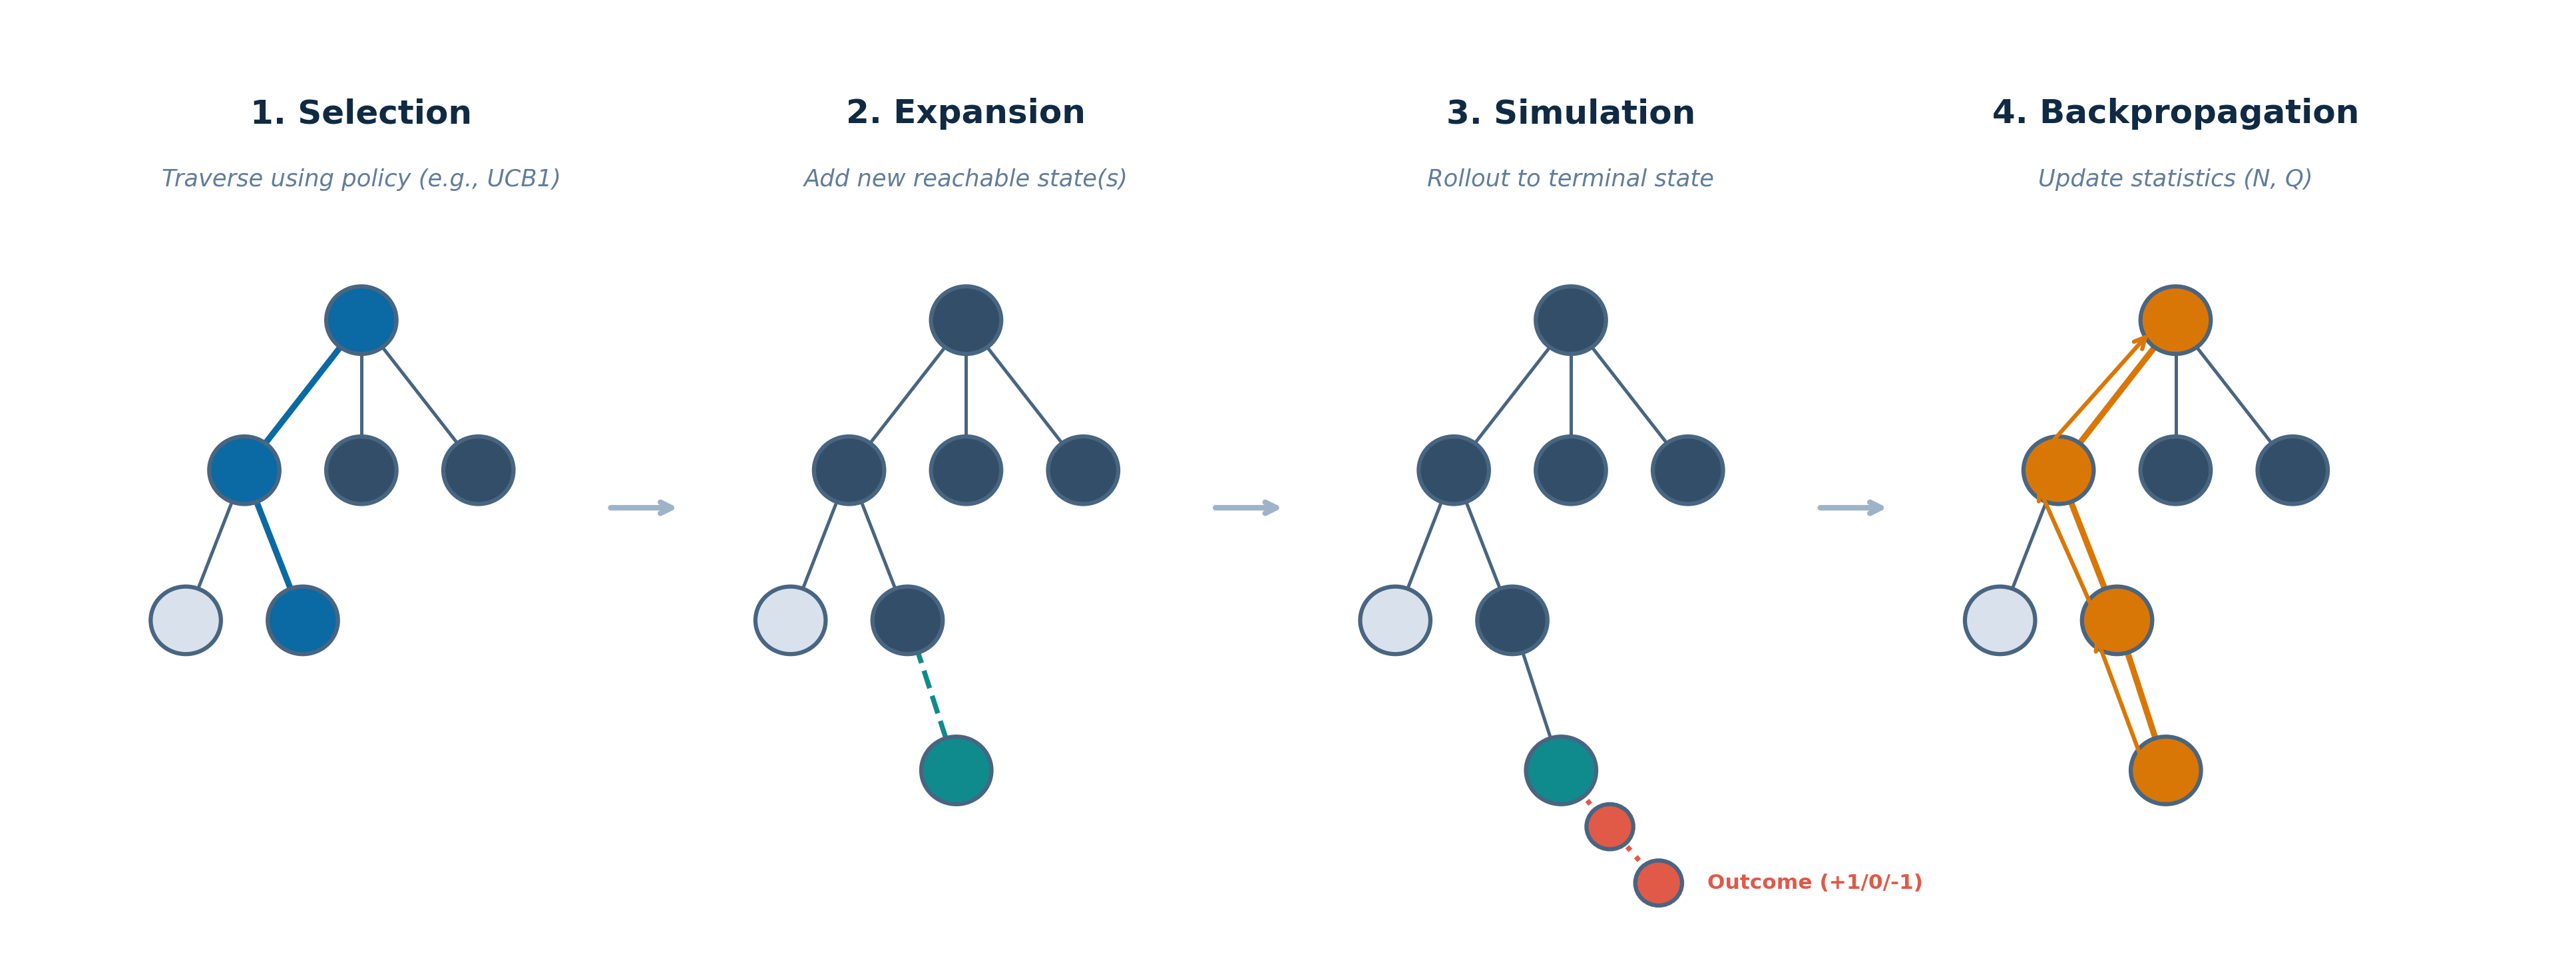

In [4]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches

# -------------------------------------------------------------
# Configuration & Setup
# -------------------------------------------------------------
fig, ax = plt.subplots(figsize=(13, 5), dpi=300)
ax.set_xlim(0, 13)
ax.set_ylim(0, 5)
ax.axis("off")

# Color palette: Academic / Clean
COLOR_BASE = "#D9E2EC"       # Inactive / unvisited nodes
COLOR_TREE = "#334E68"       # Explored tree nodes
COLOR_SELECT = "#0B69A3"     # Selected node / path
COLOR_EXPAND = "#0F8B8D"     # Newly expanded node
COLOR_SIM = "#E05A47"        # Rollout / default policy nodes
COLOR_BACKPROP = "#D97706"   # Nodes updated during backpropagation
COLOR_EDGE = "#486581"

# -------------------------------------------------------------
# Helper Functions
# -------------------------------------------------------------
def draw_node(center, color=COLOR_TREE, radius=0.18, edge_color=COLOR_EDGE, fill=True):
    return ax.add_patch(
        patches.Circle(center, radius, facecolor=color if fill else "none", 
                       edgecolor=edge_color, lw=1.5, zorder=3)
    )

def draw_edge(p1, p2, color=COLOR_EDGE, lw=1.2, ls="-"):
    ax.plot([p1[0], p2[0]], [p1[1], p2[1]], color=color, lw=lw, linestyle=ls, zorder=2)

def draw_phase(x_offset, title, desc):
    # Header card
    ax.text(x_offset + 1.25, 4.5, title, fontsize=12, fontweight="bold", 
            ha="center", va="center", color="#102A43")
    ax.text(x_offset + 1.25, 4.15, desc, fontsize=8.5, ha="center", 
            va="center", color="#627D98", style="italic")

# -------------------------------------------------------------
# Panel 1: Selection
# -------------------------------------------------------------
p1 = 0.5
draw_phase(p1, "1. Selection", "Traverse using policy (e.g., UCB1)")

# Tree coordinates relative to panel
r1 = (p1 + 1.25, 3.4)
l1 = (p1 + 0.65, 2.6)
m1 = (p1 + 1.25, 2.6)
r1_c = (p1 + 1.85, 2.6)
leaf1 = (p1 + 0.95, 1.8)

# Edges
draw_edge(r1, l1, color=COLOR_SELECT, lw=2.2)
draw_edge(r1, m1)
draw_edge(r1, r1_c)
draw_edge(l1, leaf1, color=COLOR_SELECT, lw=2.2)
draw_edge(l1, (p1 + 0.35, 1.8))

# Nodes
draw_node(r1, color=COLOR_SELECT)
draw_node(m1, color=COLOR_TREE)
draw_node(r1_c, color=COLOR_TREE)
draw_node(l1, color=COLOR_SELECT)
draw_node((p1 + 0.35, 1.8), color=COLOR_BASE)
draw_node(leaf1, color=COLOR_SELECT)  # Selected leaf node

# -------------------------------------------------------------
# Panel 2: Expansion
# -------------------------------------------------------------
p2 = 3.6
draw_phase(p2, "2. Expansion", "Add new reachable state(s)")

r2 = (p2 + 1.25, 3.4)
l2 = (p2 + 0.65, 2.6)
m2 = (p2 + 1.25, 2.6)
r2_c = (p2 + 1.85, 2.6)
leaf2 = (p2 + 0.95, 1.8)
new_node = (p2 + 1.2, 1.0)

# Edges
draw_edge(r2, l2)
draw_edge(r2, m2)
draw_edge(r2, r2_c)
draw_edge(l2, leaf2)
draw_edge(l2, (p2 + 0.35, 1.8))
draw_edge(leaf2, new_node, color=COLOR_EXPAND, lw=1.8, ls="--")

# Nodes
draw_node(r2)
draw_node(m2)
draw_node(r2_c)
draw_node(l2)
draw_node((p2 + 0.35, 1.8), color=COLOR_BASE)
draw_node(leaf2)
draw_node(new_node, color=COLOR_EXPAND)

# -------------------------------------------------------------
# Panel 3: Simulation (Rollout)
# -------------------------------------------------------------
p3 = 6.7
draw_phase(p3, "3. Simulation", "Rollout to terminal state")

r3 = (p3 + 1.25, 3.4)
l3 = (p3 + 0.65, 2.6)
m3 = (p3 + 1.25, 2.6)
r3_c = (p3 + 1.85, 2.6)
leaf3 = (p3 + 0.95, 1.8)
new_node3 = (p3 + 1.2, 1.0)
sim_terminal = (p3 + 1.7, 0.4)

# Tree edges
draw_edge(r3, l3)
draw_edge(r3, m3)
draw_edge(r3, r3_c)
draw_edge(l3, leaf3)
draw_edge(l3, (p3 + 0.35, 1.8))
draw_edge(leaf3, new_node3)

# Rollout path (dashed)
draw_edge(new_node3, (p3 + 1.45, 0.7), color=COLOR_SIM, lw=1.8, ls=":")
draw_edge((p3 + 1.45, 0.7), sim_terminal, color=COLOR_SIM, lw=1.8, ls=":")

# Nodes
draw_node(r3)
draw_node(m3)
draw_node(r3_c)
draw_node(l3)
draw_node((p3 + 0.35, 1.8), color=COLOR_BASE)
draw_node(leaf3)
draw_node(new_node3, color=COLOR_EXPAND)
draw_node((p3 + 1.45, 0.7), color=COLOR_SIM, radius=0.12)
draw_node(sim_terminal, color=COLOR_SIM, radius=0.12)
ax.text(sim_terminal[0] + 0.25, sim_terminal[1], "Outcome (+1/0/-1)", 
        fontsize=7.5, va="center", color=COLOR_SIM, fontweight="bold")

# -------------------------------------------------------------
# Panel 4: Backpropagation
# -------------------------------------------------------------
p4 = 9.8
draw_phase(p4, "4. Backpropagation", "Update statistics (N, Q)")

r4 = (p4 + 1.25, 3.4)
l4 = (p4 + 0.65, 2.6)
m4 = (p4 + 1.25, 2.6)
r4_c = (p4 + 1.85, 2.6)
leaf4 = (p4 + 0.95, 1.8)
new_node4 = (p4 + 1.2, 1.0)

# Tree edges
draw_edge(r4, l4, color=COLOR_BACKPROP, lw=2.2)
draw_edge(r4, m4)
draw_edge(r4, r4_c)
draw_edge(l4, leaf4, color=COLOR_BACKPROP, lw=2.2)
draw_edge(l4, (p4 + 0.35, 1.8))
draw_edge(leaf4, new_node4, color=COLOR_BACKPROP, lw=2.2)

# Nodes updated
draw_node(r4, color=COLOR_BACKPROP)
draw_node(m4)
draw_node(r4_c)
draw_node(l4, color=COLOR_BACKPROP)
draw_node((p4 + 0.35, 1.8), color=COLOR_BASE)
draw_node(leaf4, color=COLOR_BACKPROP)
draw_node(new_node4, color=COLOR_BACKPROP)

# Upward update arrows
for start, end in [(new_node4, leaf4), (leaf4, l4), (l4, r4)]:
    ax.annotate("", xy=(end[0] - 0.12, end[1] - 0.05), 
                xytext=(start[0] - 0.12, start[1] + 0.05),
                arrowprops=dict(arrowstyle="->", color=COLOR_BACKPROP, lw=1.5))

# -------------------------------------------------------------
# Connecting Sequence Arrows between Panels
# -------------------------------------------------------------
arrow_y = 2.4
for sep_x in [3.1, 6.2, 9.3]:
    ax.annotate("", xy=(sep_x + 0.3, arrow_y), xytext=(sep_x - 0.1, arrow_y),
                arrowprops=dict(arrowstyle="->", color="#9FB3C8", lw=2.0))

plt.tight_layout()

# Save as vector PDF and high-res PNG
plt.savefig("mcts_phases.pdf", bbox_inches="tight")
plt.savefig("mcts_phases.png", dpi=300, bbox_inches="tight")
plt.show()